<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/CASO_YOCHI_CREDITO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTAR BIBLIOTECAS

In [56]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE CASO YOCHI

In [44]:
# URL COMPLETA da sua planilha
url = "https://docs.google.com/spreadsheets/d/1wx5-acy941s93Rj79TcoYrGvQ1QAY6wwIT5taOEAp9k/edit?gid=1646585366#gid=1646585366"

# Transforma o link em formato de exportação CSV
url_csv = url.replace("/edit?", "/export?format=csv&")

# Lê os dados diretamente da planilha
base = pd.read_csv(url_csv)
base.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860,39025,HomeImp,Other,"10,5",0.0,0.0,"94,36667",1.0,9.0,NaN
1,1,1300,70053,68400,HomeImp,Other,7,0.0,2.0,"121,8333",0.0,14.0,NaN
2,1,1500,13500,16700,HomeImp,Other,4,0.0,0.0,"149,4667",1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800,112000,HomeImp,Office,3,0.0,0.0,"93,33333",0.0,14.0,NaN


In [45]:
base.dtypes

,0
BAD,int64
LOAN,int64
MORTDUE,object
VALUE,object
REASON,object
JOB,object
YOJ,object
DEROG,float64
DELINQ,float64
CLAGE,object


In [46]:
base['DEBTINC'].unique()[:20]

array([nan, '37,11361', '36,88489', '3,711312', '31,5885', '38,2636',
       '29,68183', '30,05114', '29,91586', '36,21135', '49,2064',
       '32,05978', '40,11568', '35,55354', '42,91', '0,524499',
       '35,73056', '41,51639', '29,39354', '20,47092'], dtype=object)

In [47]:
cols = ['MORTDUE','VALUE','YOJ','CLAGE','DEBTINC']

for c in cols:
    base[c] = base[c].str.replace(',', '.')
    base[c] = pd.to_numeric(base[c], errors='coerce')

VARIÁVEL RESPOSTA - BAD (clientes que não quitaram a dívida)


In [15]:
base['BAD'].value_counts()


,count
BAD,
0,4771
1,1189


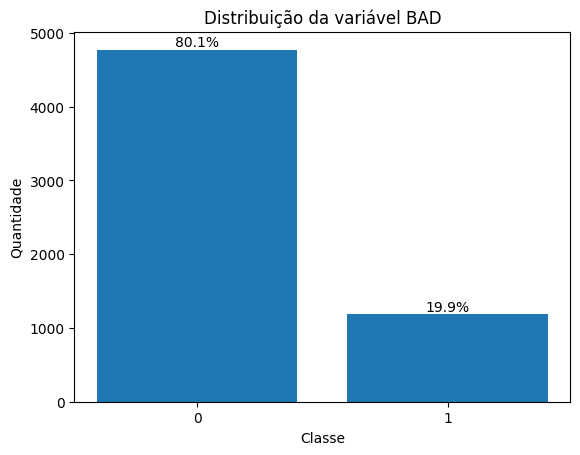

In [48]:
counts = base['BAD'].value_counts()
percent = base['BAD'].value_counts(normalize=True) * 100

plt.figure()

bars = plt.bar(counts.index.astype(str), counts.values)

plt.title('Distribuição da variável BAD')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{percent[i]:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

A distribuição da variável resposta BAD mostra que a base é desbalanceada.
Aproximadamente 80,1% dos registros pertencem à classe 0, que representa clientes não inadimplentes, enquanto 19,9% pertencem à classe 1, representando clientes inadimplentes.

VARIÁVEIS CONTÍNUAS

In [49]:
# Descritiva
base.select_dtypes(include='number').describe().T

,count,mean,std,min,25%,50%,75%,max
BAD,5960.0,0.199497,0.399656,0.000000,0.00000,0.00000,0.00000,1.0000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.00000,16300.00000,23300.00000,89900.0000
MORTDUE,5442.0,73760.817207,44457.609469,2063.000000,46276.00000,65019.00000,91488.00000,399550.0000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.50000,89235.50000,119824.25000,855909.0000
YOJ,5445.0,8.922268,7.573982,0.000000,3.00000,7.00000,13.00000,41.0000
DEROG,5252.0,0.254570,0.846047,0.000000,0.00000,0.00000,0.00000,10.0000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.00000,0.00000,0.00000,15.0000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.11670,173.46670,231.56225,1168.2340
NINQ,5450.0,1.186055,1.728675,0.000000,0.00000,1.00000,2.00000,17.0000
CLNO,5738.0,21.296096,10.138933,0.000000,15.00000,20.00000,26.00000,71.0000


In [50]:
(base.isnull().sum()/len(base))*100

,0
BAD,0.000000
LOAN,0.000000
MORTDUE,8.691275
VALUE,1.879195
REASON,4.228188
JOB,4.681208
YOJ,8.640940
DEROG,11.879195
DELINQ,9.731544
CLAGE,5.167785


A presença de valores ausentes pode impactar análises estatísticas e modelos preditivos. Portanto, será necessário avaliar estratégias de tratamento desses dados, como:

*   imputação de valores
*   remoção de observações
*   criação de categorias específicas para valores faltantes

Especialmente para a variável DEBTINC, que apresenta a maior proporção de dados ausentes, será importante avaliar a melhor forma de tratamento antes de avançar para etapas de modelagem.

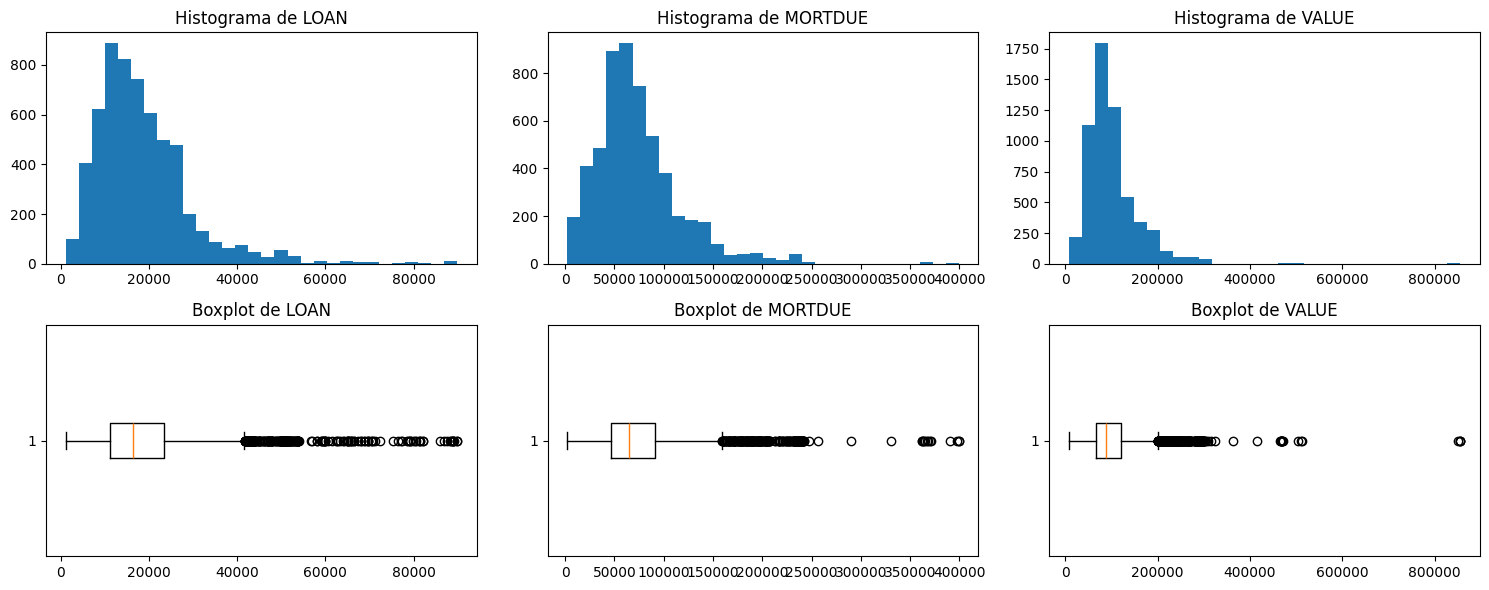

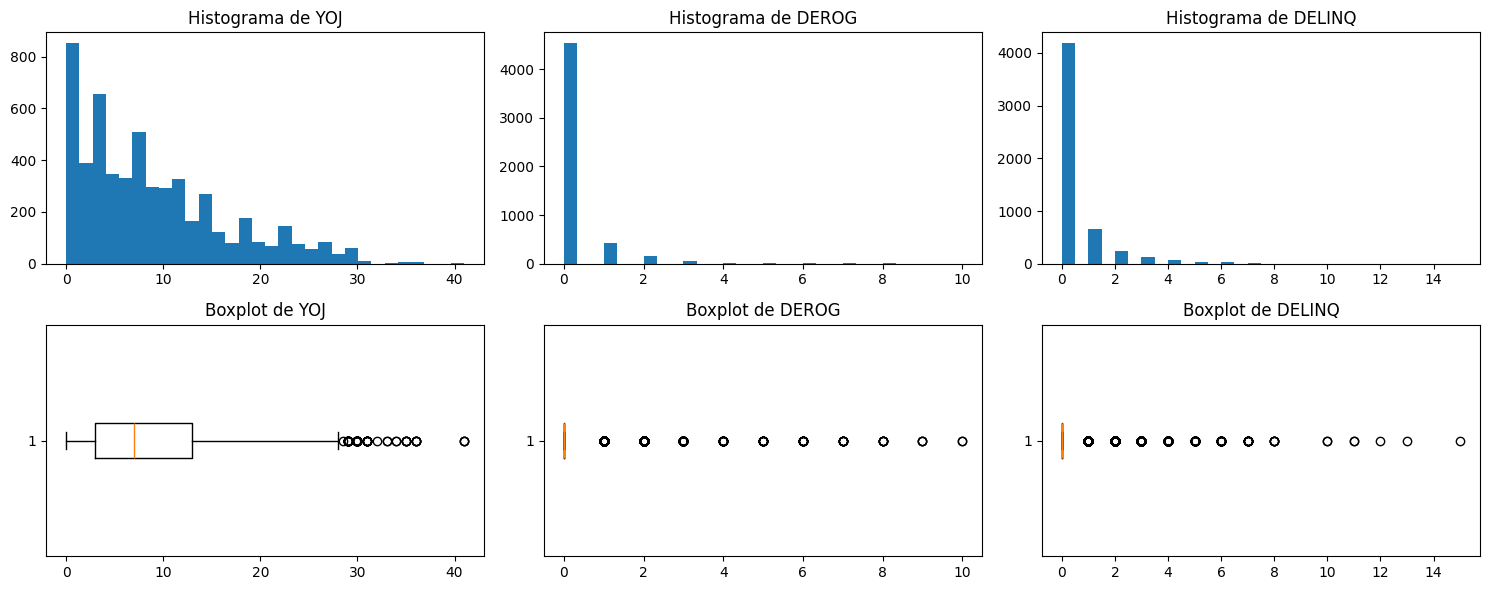

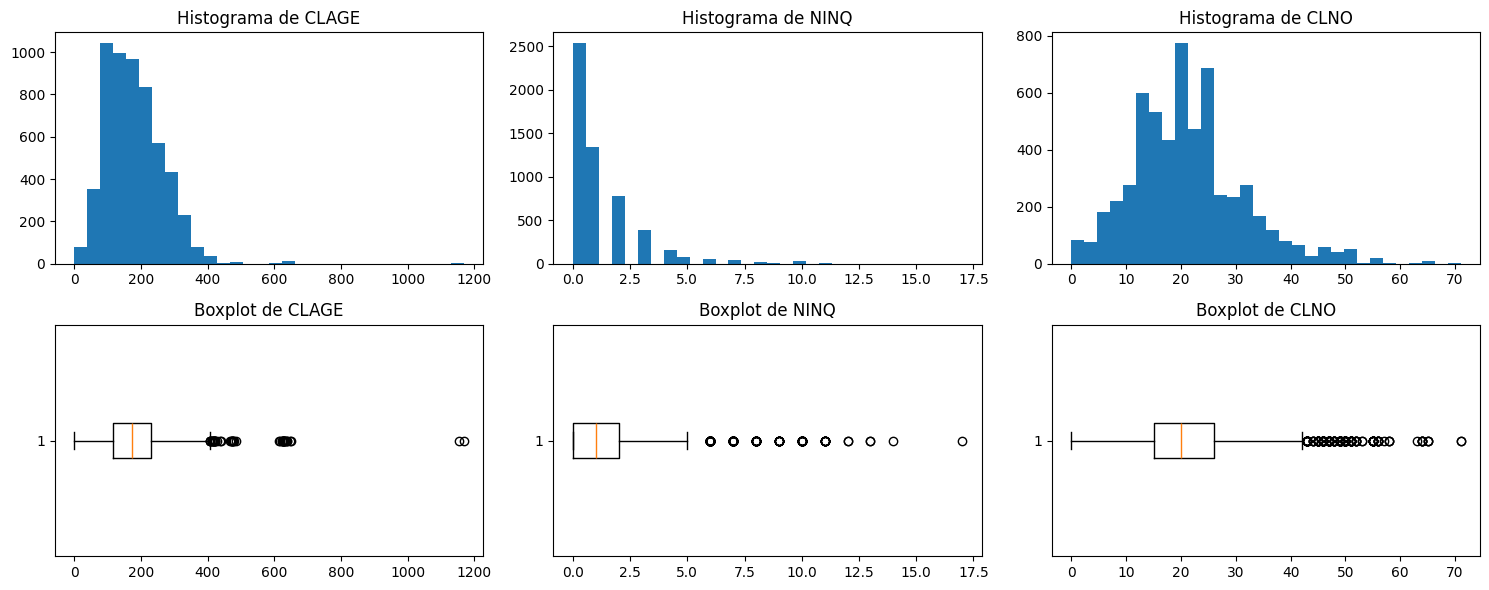

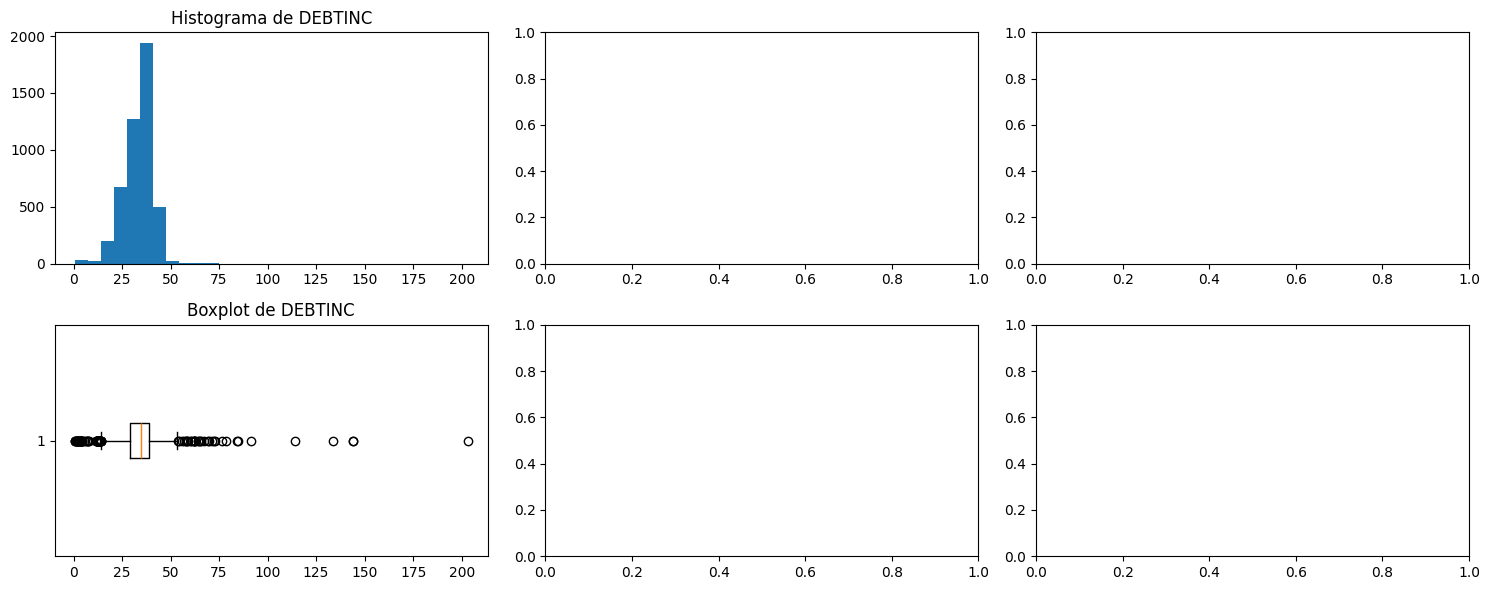

In [52]:
variaveis = ['LOAN','MORTDUE','VALUE','YOJ','DEROG','DELINQ','CLAGE','NINQ','CLNO','DEBTINC']

for i in range(0, len(variaveis), 3):

    grupo = variaveis[i:i+3]

    fig, ax = plt.subplots(2, 3, figsize=(15,6))

    for j, var in enumerate(grupo):

        dados = pd.to_numeric(base[var], errors='coerce')

        ax[0, j].hist(dados.dropna(), bins=30)
        ax[0, j].set_title(f'Histograma de {var}')

        ax[1, j].boxplot(dados.dropna(), vert=False)
        ax[1, j].set_title(f'Boxplot de {var}')

    plt.tight_layout()
    plt.show()

**LOAN** (montante do empréstimo): apresenta distribuição assimétrica à direita, com maior concentração entre aproximadamente 10 mil e 30 mil. O boxplot indica presença de outliers elevados, com alguns empréstimos chegando próximos de 90 mil.

**MORTDUE** (montante devido a hipoteca ativa): assimetria positiva. A maior parte dos valores concentra-se aproximadamente entre 40 mil e 120 mil, porém existem valores extremos elevados, chegando próximos de 400 mil.

**VALUE** (valor da propriedade atual): apresenta distribuição bastante assimétrica à direita, com concentração principal abaixo de 200 mil. Observam-se outliers muito altos, com alguns imóveis acima de 800 mil.

**YOJ** (anos no emprego atual): apresenta maior concentração de valores entre 0 e 10 anos. A distribuição é assimétrica à direita, com poucos indivíduos com mais de 30 anos de emprego, considerados outliers.

**DEROG** (número de relatórios depreciativos): apresenta forte concentração no valor zero, indicando que a maioria dos clientes não possui registros negativos. Valores maiores são pouco frequentes e aparecem como outliers discretos.

**DELINQ** (número de linhas de crédito inadimplentes): apresenta concentração em valores baixos, principalmente 0 ou 1, com poucos casos de atrasos mais elevados.

**CLAGE** (tempo que tem a mais antiga conta - em meses): apresenta distribuição aproximadamente assimétrica à direita, com maior concentração entre 100 e 300 meses, além de alguns outliers elevados.

**NINQ** (consultas de crédito recentes): apresenta grande concentração em valores baixos, especialmente 0 a 2 consultas, com poucos casos acima de 10 consultas, caracterizando outliers.

**CLNO** (número de linhas de crédito): apresenta distribuição relativamente mais espalhada, com maior concentração entre 10 e 30 linhas, mas também apresenta alguns valores extremos acima de 60.

**DEBTINC** (relação dívida/renda): apresenta distribuição aproximadamente concentrada entre 20 e 50, com presença de alguns outliers elevados, indicando clientes com alto comprometimento da renda com dívidas.

VARIÁVEIS CATEGÓRICAS

/tmp/ipykernel_443/478745811.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{percent[i]:.1f}%',


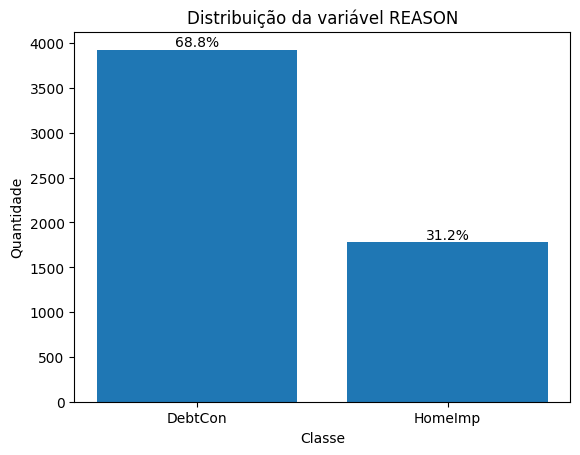

In [54]:
counts = base['REASON'].value_counts()
percent = base['REASON'].value_counts(normalize=True) * 100

plt.figure()

bars = plt.bar(counts.index.astype(str), counts.values)

plt.title('Distribuição da variável REASON')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{percent[i]:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

/tmp/ipykernel_443/2805363641.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'{percent[i]:.1f}%',


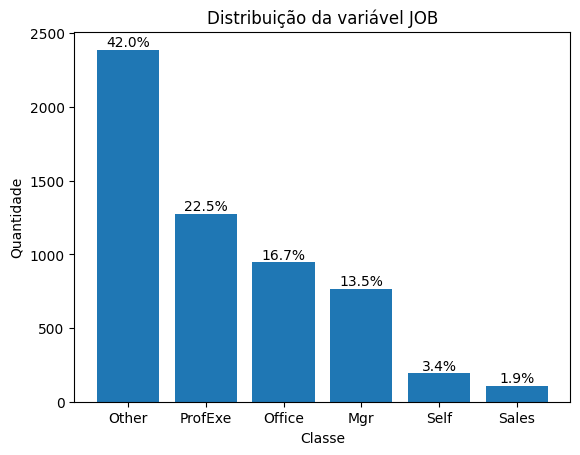

In [55]:
counts = base['JOB'].value_counts()
percent = base['JOB'].value_counts(normalize=True) * 100

plt.figure()

bars = plt.bar(counts.index.astype(str), counts.values)

plt.title('Distribuição da variável JOB')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{percent[i]:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

Variável REASON:

A variável REASON, que representa o motivo do empréstimo, apresenta predominância da categoria DebtCon, responsável por aproximadamente 68,8% das observações. A categoria HomeImp, relacionada a melhorias residenciais, corresponde a cerca de 31,2% da base.

Isso indica que a maior parte dos empréstimos concedidos na base está associada à consolidação de dívidas, enquanto uma parcela menor está relacionada a melhorias no imóvel.

Variável JOB:

A variável JOB, que representa a ocupação do cliente, apresenta maior concentração na categoria Other, que corresponde a aproximadamente 42% das observações. Em seguida aparecem ProfExe (22,5%), Office (16,7%) e Mgr (13,5%).

As categorias Self (3,4%) e Sales (1,9%) possuem menor representatividade na base.

De forma geral, observa-se uma distribuição desigual entre as categorias de ocupação, com predominância de algumas categorias específicas.

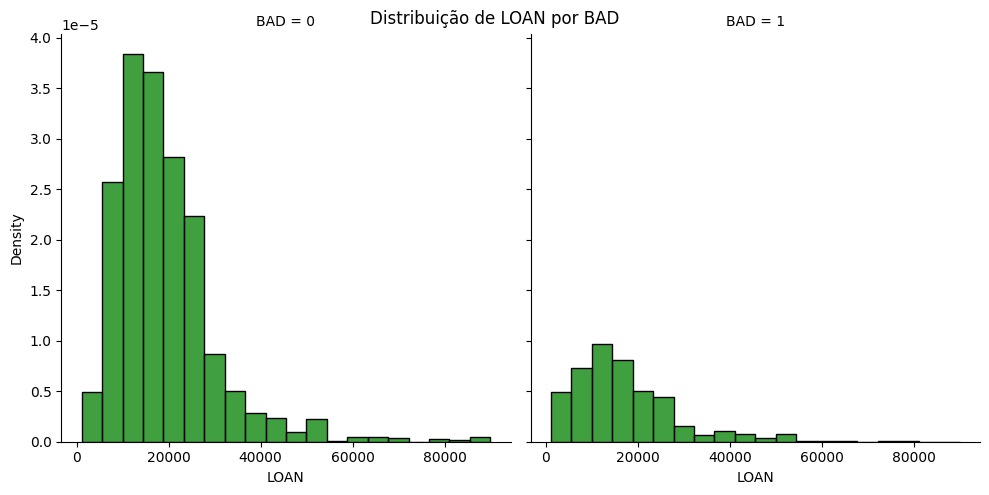

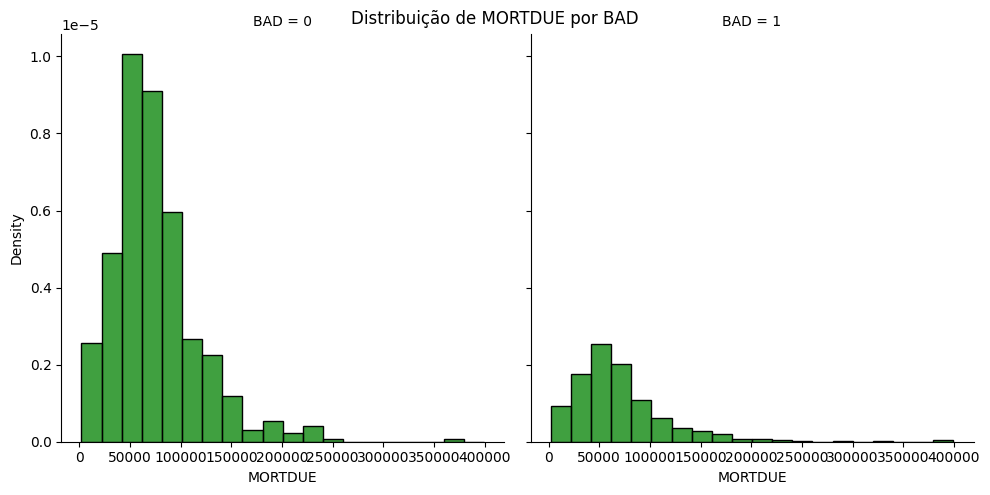

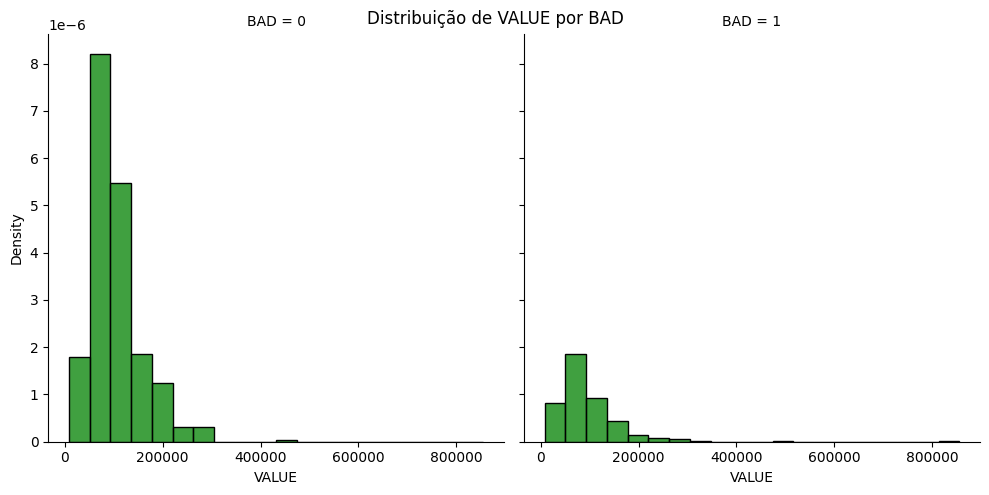

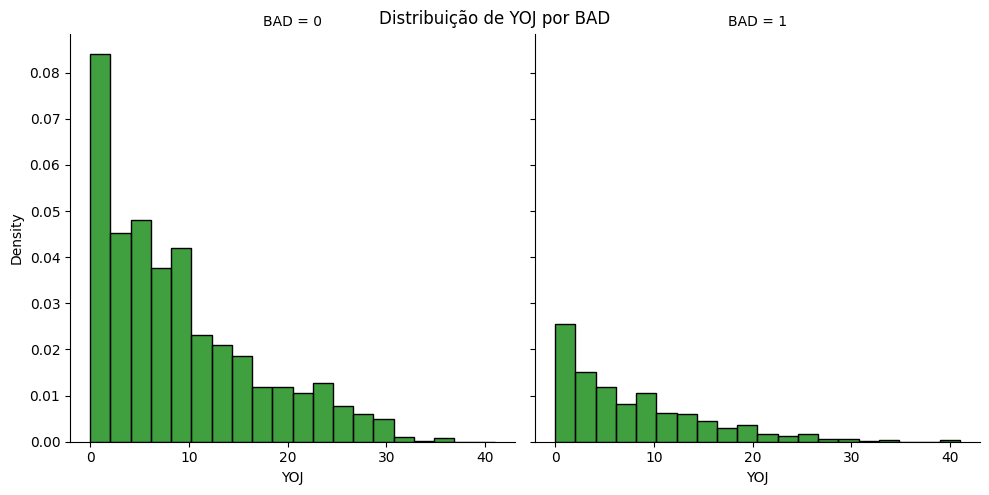

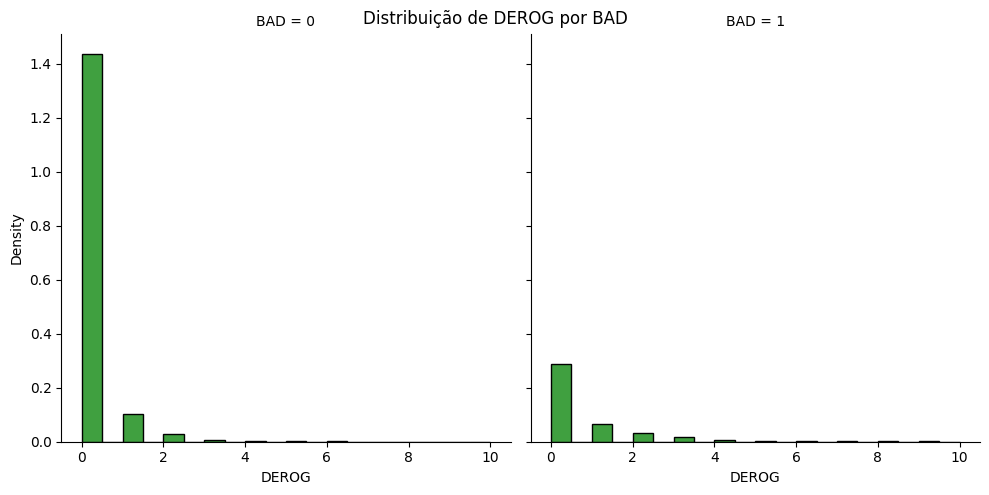

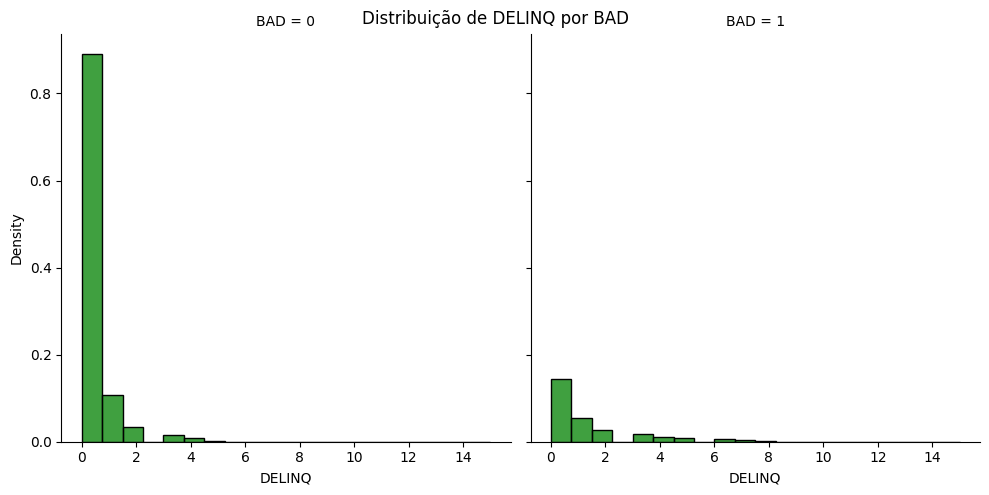

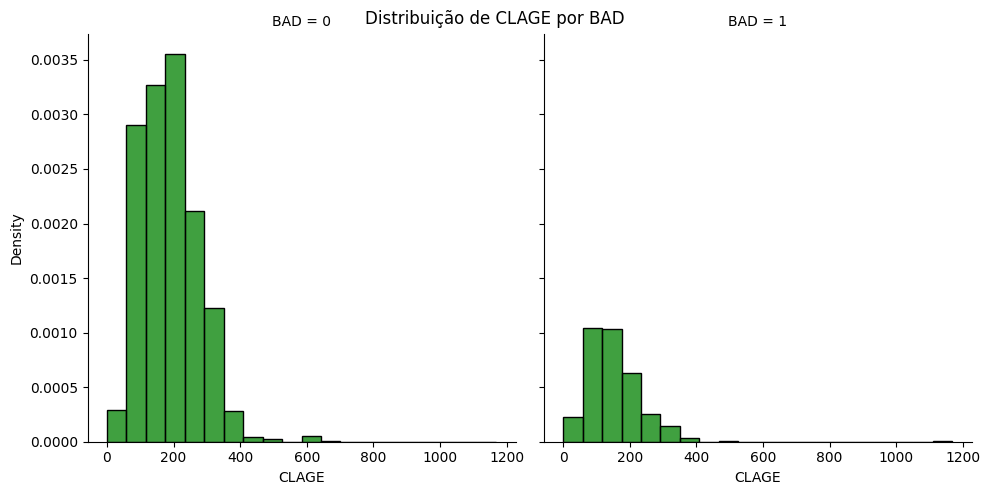

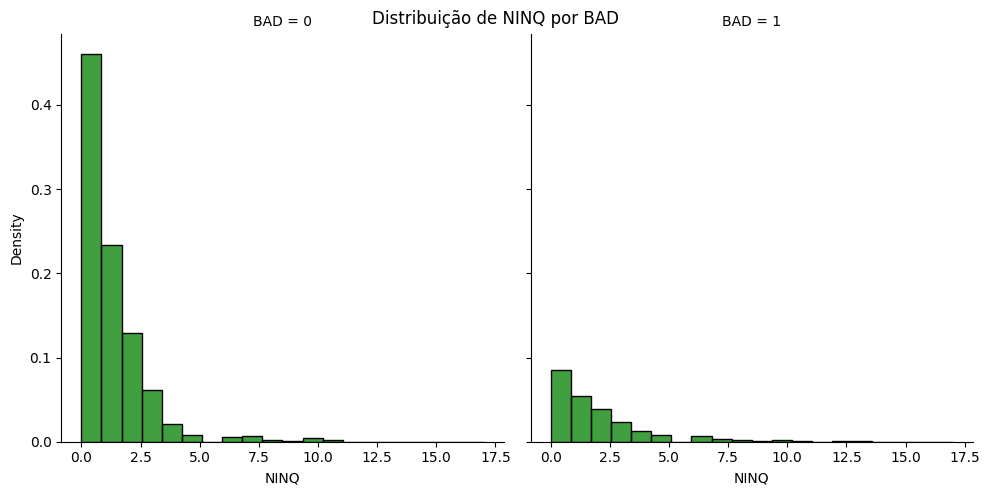

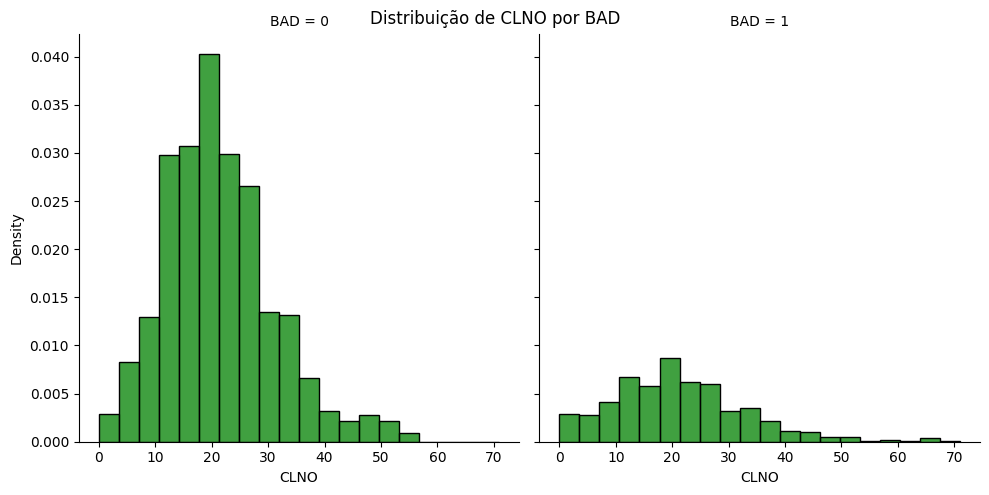

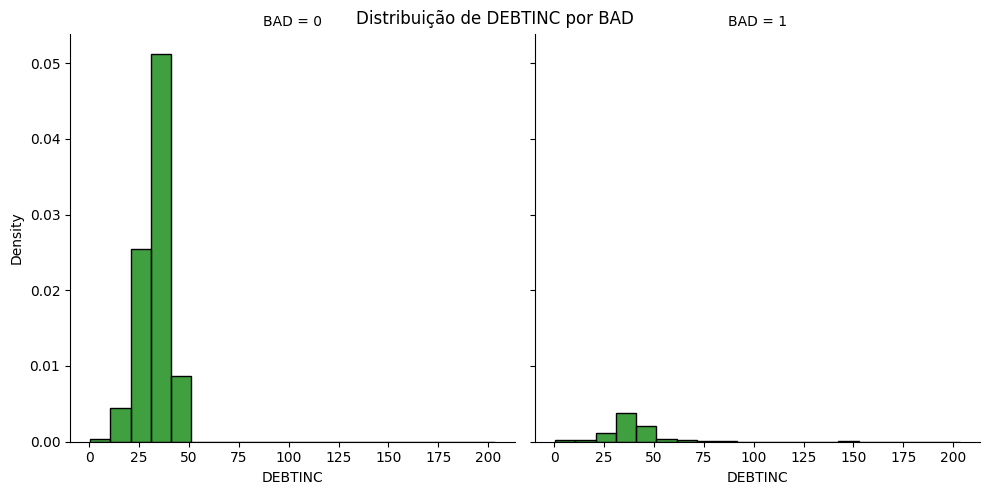

In [59]:
for var in variaveis:

    sns.displot(
        base,
        x=var,
        col="BAD",
        multiple="dodge",
        color="g",
        stat="density",
        bins=20
    )

    plt.suptitle(f'Distribuição de {var} por BAD')
    plt.show()